In [71]:
import pandas as pd
from matplotlib import pyplot as plt


## С ручными распределениями все ок

In [72]:
df = pd.read_json('kolosman_24_02.json', encoding='utf-8-sig')

In [73]:
df[df['number'] == 26831]['cash_flow_item_code']

58834    122
Name: cash_flow_item_code, dtype: int64

In [74]:
# df[df['cash_flow_details_code'].str.strip() == '']['number']

In [75]:
df_old = pd.read_json('../5/manual_kolos_12_01.json', encoding='utf-8-sig')

(array([ 1916.,   547.,   524.,   880.,  1809., 12337.,     0.,     0.,
         1749.,   801.]),
 array([ 13. ,  33.5,  54. ,  74.5,  95. , 115.5, 136. , 156.5, 177. ,
        197.5, 218. ]),
 <BarContainer object of 10 artists>)

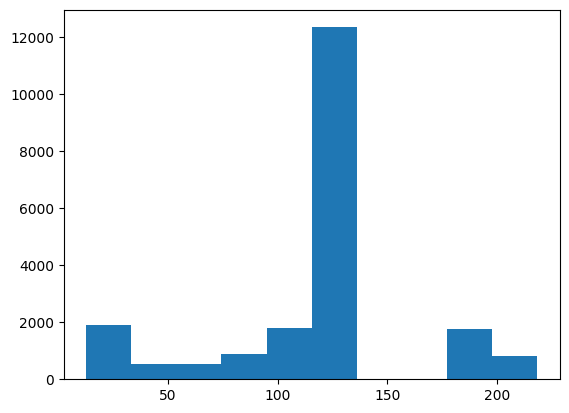

In [76]:
plt.hist(df_old['cash_flow_item_code'])

(array([41855.,  4495.,  3064.,  3925.,   858.,  3281.,  4623.,   368.,
         4810.,  2967.]),
 array([ 10. ,  73.7, 137.4, 201.1, 264.8, 328.5, 392.2, 455.9, 519.6,
        583.3, 647. ]),
 <BarContainer object of 10 artists>)

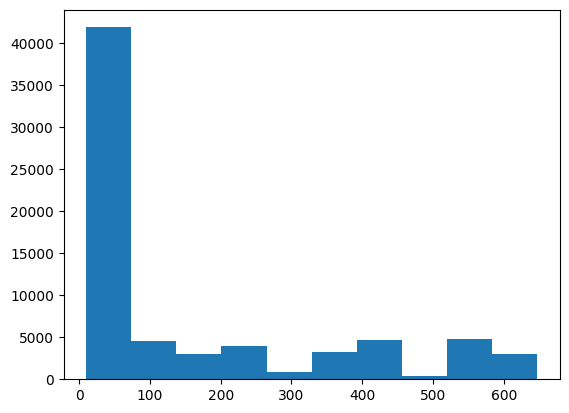

In [77]:
plt.hist(df['cash_flow_details_code'].replace('', -1).astype(int))

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70246 entries, 0 to 70245
Data columns (total 47 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   number                        70246 non-null  int64         
 1   date                          70246 non-null  datetime64[ns]
 2   is_reverse                    70246 non-null  object        
 3   moving_type                   70246 non-null  object        
 4   base_document_number          70246 non-null  object        
 5   base_document_date            70246 non-null  object        
 6   base_document_kind            70246 non-null  object        
 7   base_document_operation_type  70246 non-null  object        
 8   company_inn                   70246 non-null  int64         
 9   company_kpp                   70246 non-null  int64         
 10  kind                          70246 non-null  object        
 11  contractor_kind             

In [79]:
df_old.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20563 entries, 0 to 20562
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   number                        20563 non-null  int64         
 1   date                          20563 non-null  datetime64[ns]
 2   is_reverse                    20563 non-null  object        
 3   moving_type                   20563 non-null  object        
 4   base_document_number          20563 non-null  object        
 5   base_document_date            20563 non-null  object        
 6   base_document_kind            20563 non-null  object        
 7   base_document_operation_type  20563 non-null  object        
 8   company_inn                   20563 non-null  int64         
 9   company_kpp                   20563 non-null  int64         
 10  kind                          20563 non-null  object        
 11  contractor_kind             

In [80]:
df['cash_flow_item_code'] = df['cash_flow_item_code'].replace('', -1).astype(int)

In [81]:
df_old['cash_flow_item_code'] = df_old['cash_flow_item_code'].fillna(-1)

In [82]:
# агрегируем множества кодов по документу
g1 = df.groupby('number')['cash_flow_item_code'].agg(lambda x: set(x.dropna()))
g2 = df_old.groupby('number')['cash_flow_item_code'].agg(lambda x: set(x.dropna()))

# объединяем в один датафрейм
cmp = (
    g1.rename('new_codes')
    .to_frame()
    .merge(
        g2.rename('old_codes'),
        left_index=True,
        right_index=True,
        how='outer'
    )
)

# заменим NaN на пустые множества
cmp['new_codes'] = cmp['new_codes'].apply(lambda x: x if isinstance(x, set) else set())
cmp['old_codes'] = cmp['old_codes'].apply(lambda x: x if isinstance(x, set) else set())

# оставим только различия
diff = cmp[cmp['new_codes'] != cmp['old_codes']]

print(diff)

       new_codes   old_codes
number                      
5365       {186}  {186, 204}
5603       {184}  {184, 186}
5604       {186}  {186, 204}
5607       {204}  {186, 204}
5923       {184}  {184, 186}
...          ...         ...
26828      {122}          {}
26829      {122}          {}
26830      {122}          {}
26831      {122}          {}
26832       {40}          {}

[2356 rows x 2 columns]


In [83]:
diff['only_in_new'] = diff['new_codes'] - diff['old_codes']
diff['only_in_old'] = diff['old_codes'] - diff['new_codes']
diff

C:\Users\SVKravchenko\AppData\Local\Temp\ipykernel_18032\732967375.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff['only_in_new'] = diff['new_codes'] - diff['old_codes']
C:\Users\SVKravchenko\AppData\Local\Temp\ipykernel_18032\732967375.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff['only_in_old'] = diff['old_codes'] - diff['new_codes']


,new_codes,old_codes,only_in_new,only_in_old
number,,,,
5365,{186},"{186, 204}",{},{204}
5603,{184},"{184, 186}",{},{186}
5604,{186},"{186, 204}",{},{204}
5607,{204},"{186, 204}",{},{186}
5923,{184},"{184, 186}",{},{186}
...,...,...,...,...
26828,{122},{},{122},{}
26829,{122},{},{122},{}
26830,{122},{},{122},{}


In [84]:
diff[diff['old_codes'] != set()]

,new_codes,old_codes,only_in_new,only_in_old
number,,,,
5365,{186},"{186, 204}",{},{204}
5603,{184},"{184, 186}",{},{186}
5604,{186},"{186, 204}",{},{204}
5607,{204},"{186, 204}",{},{186}
5923,{184},"{184, 186}",{},{186}
...,...,...,...,...
24707,{41},{126},{41},{126}
24709,{41},{126},{41},{126}
24713,"{126, 38}",{38},{126},{}


In [85]:
cmp

,new_codes,old_codes
number,,
5337,{33},{33}
5338,{33},{33}
5339,{33},{33}
5340,{80},{80}
5341,{33},{33}
...,...,...
26828,{122},{}
26829,{122},{}
26830,{122},{}


In [86]:
df['number'].unique()

array([7658, 7659, 7660, ..., 7598, 7599, 7653], shape=(21478,))

In [87]:
df_old['number'].unique()

array([7658, 7659, 7660, ..., 7598, 7599, 7653], shape=(19364,))

In [88]:
df[df['number'] == 26831]['cash_flow_item_code']

58834    122
Name: cash_flow_item_code, dtype: int64

## Автоматическое vs автоматическое

In [ ]:
df = pd.read_json('kolosaut_24_02.json', encoding='utf-8-sig')

In [89]:
df_old = pd.read_json('../5/auto_kolos_14_01.json', encoding='utf-8-sig')

In [90]:
df['article_name']

0                                                         
1                                                         
2                                                         
3                                                         
4                                                         
                               ...                        
70241    Договор об открытии НКЛ № 520B0065QMF от 17.06...
70242                 Договор займа № 271 от 22.10.2020 г.
70243                 Договор займа № 271 от 22.10.2020 г.
70244                                                     
70245                                                     
Name: article_name, Length: 70246, dtype: object

In [100]:

g1 = df.groupby('number')[['article_group', 'article_kind', 'article_parent', 'article_name']].apply(lambda x: set(x.replace('', None).dropna().values.ravel()))
g2 = df_old.groupby('number')[['article_group', 'article_kind', 'article_parent', 'article_name']].apply(lambda x: set(x.replace('', None).dropna().values.ravel()))

# объединяем в один датафрейм
cmp = (
    g1.rename('new_codes')
    .to_frame()
    .merge(
        g2.rename('old_codes'),
        left_index=True,
        right_index=True,
        how='outer'
    )
)

# заменим NaN на пустые множества
cmp['new_codes'] = cmp['new_codes'].apply(lambda x: x if isinstance(x, set) else set())
cmp['old_codes'] = cmp['old_codes'].apply(lambda x: x if isinstance(x, set) else set())

# оставим только различия
diff = cmp[cmp['new_codes'] != cmp['old_codes']]

print(diff)

                                                new_codes  \
number                                                      
225                                                    {}   
226                                                    {}   
227                                                    {}   
229                                                    {}   
230                                                    {}   
...                                                   ...   
26731   {2025, Горох 2025, Продукция растениеводства, ...   
26732   {2025, Горох 2025, Продукция растениеводства, ...   
26765   {Озимая пшеница 2 сорт 2025, Продукция растени...   
26766   {2025, Горох 2025, Продукция растениеводства, ...   
26817   {Озимая пшеница 2 сорт 2025, Продукция растени...   

                                                old_codes  
number                                                     
225     {Продукция растениеводства, Озимая пшеница 2 с...  
226     {Продукция растени

In [ ]:
diff['only_in_new'] = diff['new_codes'] - diff['old_codes']
diff['only_in_old'] = diff['old_codes'] - diff['new_codes']
diff


C:\Users\SVKravchenko\AppData\Local\Temp\ipykernel_18032\732967375.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff['only_in_new'] = diff['new_codes'] - diff['old_codes']
C:\Users\SVKravchenko\AppData\Local\Temp\ipykernel_18032\732967375.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff['only_in_old'] = diff['old_codes'] - diff['new_codes']


,new_codes,old_codes,only_in_new,only_in_old
number,,,,
225,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
226,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
227,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
229,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
230,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
...,...,...,...,...
26731,"{2025, Горох 2025, Продукция растениеводства, ...",{},"{2025, Горох 2025, Продукция растениеводства, ...",{}
26732,"{2025, Горох 2025, Продукция растениеводства, ...",{},"{2025, Горох 2025, Продукция растениеводства, ...",{}
26765,"{Озимая пшеница 2 сорт 2025, Продукция растени...",{},"{Озимая пшеница 2025, Озимая пшеница 2 сорт 20...",{}


In [102]:
diff[diff['old_codes'] != set()]

,new_codes,old_codes,only_in_new,only_in_old
number,,,,
225,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
226,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
227,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
229,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
230,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
...,...,...,...,...
23978,{},"{Продукция растениеводства, Озимый ячмень 2025...",{},"{Продукция растениеводства, Озимый ячмень 2025..."
24074,"{Для договоров 2025, Продукция растениеводства...","{Продукция растениеводства, Озимый ячмень 2025...",{2025},{}
24145,{},"{Продукция растениеводства, Озимый ячмень 2025...",{},"{Продукция растениеводства, Озимый ячмень 2025..."


## Автоматическое vs ручное по новому

In [103]:
df = pd.read_json('kolosaut_24_02.json', encoding='utf-8-sig')

In [104]:
df_man = pd.read_json('kolosman_24_02.json', encoding='utf-8-sig')

In [105]:
df['article_name']

0                                                         
1                                                         
2                                                   Услуги
3                                                   Услуги
4                                                   Услуги
                               ...                        
62202                                             Литол-24
62203    Проведение санитарно-бактериологических, санит...
62204    Договор об открытии НКЛ № 520B0065QMF от 17.06...
62205                 Договор займа № 271 от 22.10.2020 г.
62206                                                     
Name: article_name, Length: 62207, dtype: object

In [106]:

g1 = df.groupby('number')[['article_group', 'article_kind', 'article_parent', 'article_name']].apply(lambda x: set(x.replace('', None).dropna().values.ravel()))
g2 = df_old.groupby('number')[['article_group', 'article_kind', 'article_parent', 'article_name']].apply(lambda x: set(x.replace('', None).dropna().values.ravel()))

# объединяем в один датафрейм
cmp = (
    g1.rename('new_codes')
    .to_frame()
    .merge(
        g2.rename('old_codes'),
        left_index=True,
        right_index=True,
        how='outer'
    )
)

# заменим NaN на пустые множества
cmp['new_codes'] = cmp['new_codes'].apply(lambda x: x if isinstance(x, set) else set())
cmp['old_codes'] = cmp['old_codes'].apply(lambda x: x if isinstance(x, set) else set())

# оставим только различия
diff = cmp[cmp['new_codes'] != cmp['old_codes']]

print(diff)

                                                new_codes  \
number                                                      
225                                                    {}   
226                                                    {}   
227                                                    {}   
229                                                    {}   
230                                                    {}   
...                                                   ...   
26731   {2025, Горох 2025, Продукция растениеводства, ...   
26732   {2025, Горох 2025, Продукция растениеводства, ...   
26765   {Озимая пшеница 2 сорт 2025, Продукция растени...   
26766   {2025, Горох 2025, Продукция растениеводства, ...   
26817   {Озимая пшеница 2 сорт 2025, Продукция растени...   

                                                old_codes  
number                                                     
225     {Продукция растениеводства, Озимая пшеница 2 с...  
226     {Продукция растени

In [107]:
diff['only_in_new'] = diff['new_codes'] - diff['old_codes']
diff['only_in_old'] = diff['old_codes'] - diff['new_codes']
diff


C:\Users\SVKravchenko\AppData\Local\Temp\ipykernel_18032\4174623976.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff['only_in_new'] = diff['new_codes'] - diff['old_codes']
C:\Users\SVKravchenko\AppData\Local\Temp\ipykernel_18032\4174623976.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff['only_in_old'] = diff['old_codes'] - diff['new_codes']


,new_codes,old_codes,only_in_new,only_in_old
number,,,,
225,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
226,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
227,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
229,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
230,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
...,...,...,...,...
26731,"{2025, Горох 2025, Продукция растениеводства, ...",{},"{2025, Горох 2025, Продукция растениеводства, ...",{}
26732,"{2025, Горох 2025, Продукция растениеводства, ...",{},"{2025, Горох 2025, Продукция растениеводства, ...",{}
26765,"{Озимая пшеница 2 сорт 2025, Продукция растени...",{},"{Озимая пшеница 2025, Озимая пшеница 2 сорт 20...",{}


In [108]:
diff[diff['old_codes'] != set()]

,new_codes,old_codes,only_in_new,only_in_old
number,,,,
225,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
226,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
227,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
229,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
230,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
231,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
232,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
429,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
430,{},"{Продукция растениеводства, Озимая пшеница 2 с...",{},"{Продукция растениеводства, Озимая пшеница 2 с..."
